# Alternative Data Types
In the previous section, we discussed how some types of outcome variable are unsuitable for modelling with a normal distribution. We demonstrated the issues when using a *binary* outcome, but this was just one example. To give a better sense of the variety of data we may collect, and how it can be modelled probabilistically, this part of the lesson will introduce some different types of data and their associated distributions. This provides the starting point for considering how these different types can be modelled.

## Distributions of Alternative Data Types 
We will work through a number of commonly-used probability distributions and the types of data they are associated with. We start from the perspective of the *distribution* because we require a probability distribution in order to actually model the data. In all cases, remember that the distribution is an *idealised* representation of reality. Some of these distributions have more control over their shape and some have less, meaning that some can be more flexibly applied to data than others. In the same way that not all continuous data will fit a normal distribution, not all real world data will fit these distributions. However, they all represent that starting point for moving beyond the normal linear model for cases where it is not appropriate.

### The Bernoulli Distribution
The Bernoulli distribution can be used as a model of *binary* data. It is defined very simply: for a random variable $y$ that can take on a value of either 1 or 0 we have

$$
\begin{align*}
    P(y=1) &= p      \\
    P(y=0) &= 1 - p. \\
\end{align*}
$$

As such, the Bernoulli distribution only has one parameter, called $p$, that gives the probability of a value of 1. This is often referred to as the probability of a "success" [^foot-1]. The expected value and variance are then given by

$$
\begin{align*}
    E(y)          &= p         \\
    \text{Var}(y) &= p(1 - p). \\
\end{align*}
$$

[^foot-1]: This can be an unfortunate convention, especially when applying models like this to experiments such as counting each rat that died under an experimental treatment as a "success". 

A plot of the Bernoulli distribution is given below for $p = 0.4$.

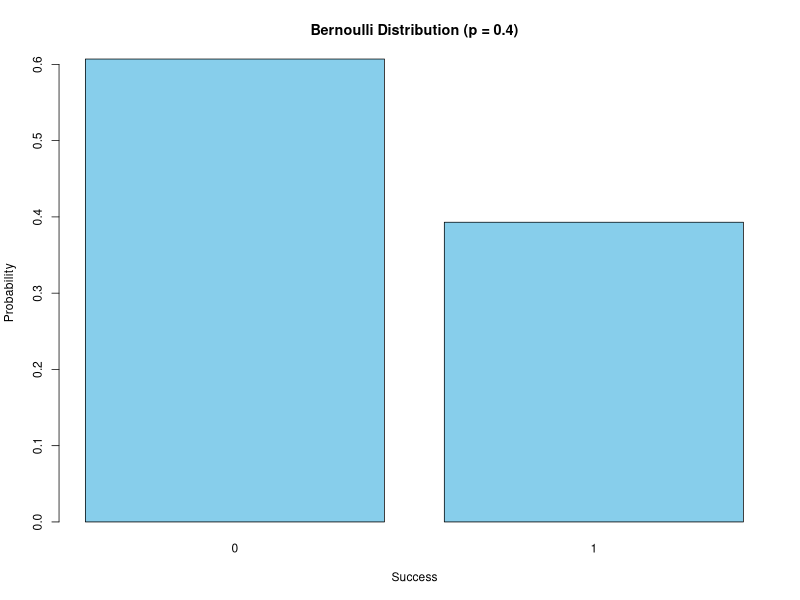

In [5]:
set.seed(123)
p <- 0.4
y <- rbinom(n=1000, size=1, prob=p)
barplot(table(y)/1000,
        col='skyblue',
        xlab="Success", 
        ylab="Probability", 
        main=paste0("Bernoulli Distribution (p = ", p,")"))

To see how the Bernoulli distribution could be used in conjunction with a continuous predictor variable, consider the example from earlier of failures in an industrial process in relation to temperature. As temperature goes up, we expect the probability of failure to also go up. Much like the normal linear model, we are modelling the expected value of the outcome as conditional on the value of the predictor. The only difference is that this expected value is the probability of "success". This results in the model shown in [](#fig-binary-bernoulli-3D).

```{figure} images/binary_bernoulli_3D.gif
:label: fig-binary-bernoulli-3D
:alt: Example of a Bernoulli probability model for a binary outcome and a continuous predictor.
:align: center

Example of a Bernoulli probability model for a binary outcome and a continuous predictor.
```


Of importance is that, because probability does not simply increase as a straight line, we end up with a different shape compared to a regression line. This is because probability is bounded between 0 and 1 and must therefore flatten-off as it approaches either extreme. This S-shaped curve will become a familiar sight as we progress.

```{admonition} Bernoulli in Practice
Here are some examples of experiments from psychology and cognitive neuroscience that could be modelled using a Bernoulli distribution:
- Whether a subject detected a faint visual stimulus on a trial.
- Whether a memory item was recalled correctly or not.
- Whether a subject made a correct response on a single trial.
```

### The Binomial distribution
As the size is generally fixed, it is only the probability that we model, in much the same vein as the Bernoulli distribution.

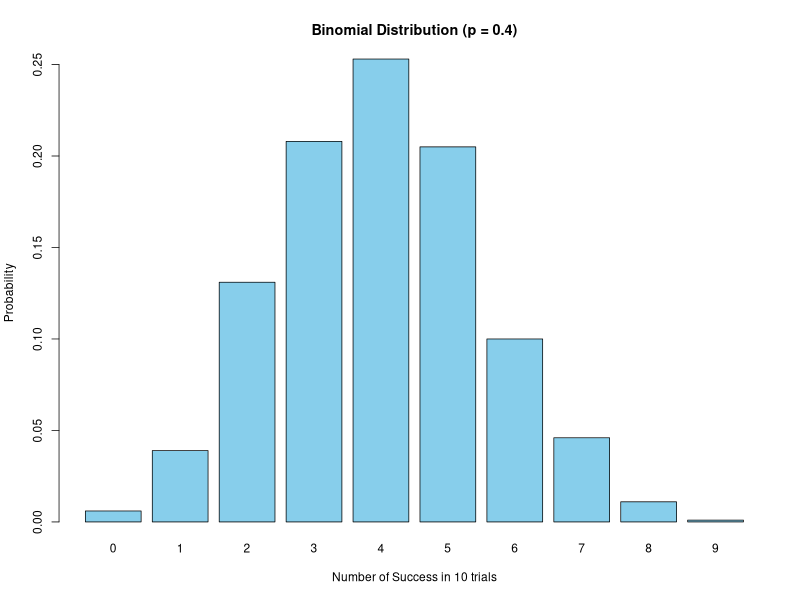

In [2]:
set.seed(123)
p <- 0.4
y <- rbinom(n=1000, size=10, prob=p)
barplot(table(y)/1000,
        col='skyblue',
        xlab="Number of Success in 10 trials", 
        ylab="Probability", 
        main=paste0("Binomial Distribution (p = ", p,")"))


As an example, imagine we were investigating the same industrial process as used as an example above. However, this time we can only run the manufacturing process in batches of 10 at a given temperature. Our outcome variable is then a count of the number of defective products for each batch. 

```{figure} images/count_binomial_3D.gif
:label: fig-count-binomial-3D
:alt: Example of a binomial probability model for a count outcome and a continuous predictor.
:align: center

Example of a binomial probability model for a count outcome and a continuous predictor. Remember that the distributions are defined along the $y$-axis for each value of temperature.
```

Notice how this follows a similar shape to the Bernoulli example, precisely because counts are bounded. We cannot have a count smaller than 0 or larger than 10 (the maximum number of defective products in a batch). So notice how the distribution naturally truncates at these extremes. Furthermore, notice that the distribution only has probability mass at whole numbers, reflecting the fact that a count cannot be fractional. If we had used a normal distribution here, not only would the probability extend below 0 and above 10, but values in between the counts would also have some non-zero probability.

```{admonition} Binomial in Practice
Here are some examples of experiments from psychology and cognitive neuroscience that could be modelled using a binomial distribution:
- Number of correct responses out of 20 trials at each stimulus intensity.
- Number of remembered words out of a fixed list of 15.
- Number of successfully inhibited responses out of 30 stop-signal trials.
```

### The Poisson and Negative Binomial Distributions

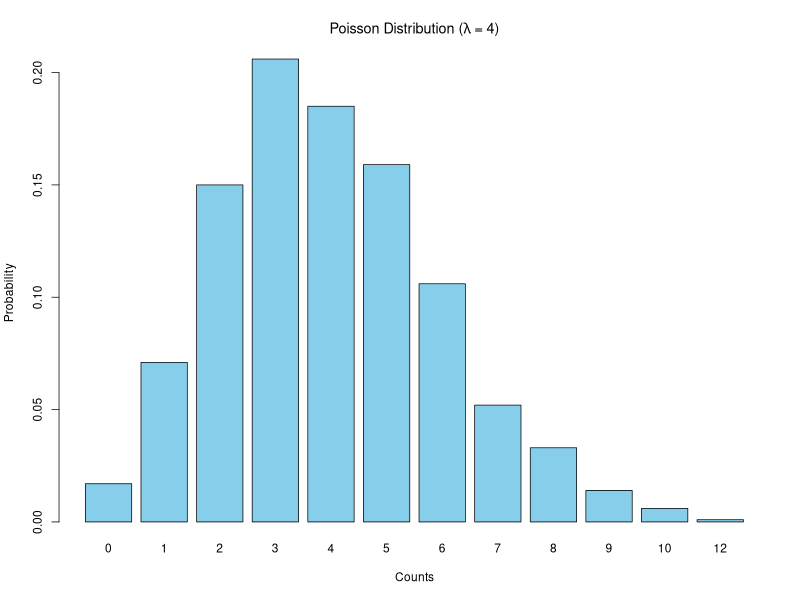

In [ ]:
set.seed(123)
y <- rpois(n=1000, lambda=4)
barplot(table(y)/1000,
        col='skyblue',
        xlab="Counts", 
        ylab="Probability", 
        main=expression(paste("Poisson Distribution (", lambda, " = 4)")))

Note that the Poisson model has no upper-bound, only a lower-bound, because there is no real maximum possible number of defective items in the same way as the maximum count under the binomial model.

```{figure} images/count_poisson_3D.gif
:label: fig-count-binomial-3D
:alt: Example of a Poisson probability model for a count outcome and a continuous predictor.
:align: center

Example of a Poisson probability model for a count outcome and a continuous predictor. Remember that the distributions are defined along the $y$-axis for each value of temperature.
```

The negative binomial distribution is very similar in spirit to the Poisson distribution. However, the main difference is that ...

```{admonition} Poisson/Negative Binomial in Practice
Here are some examples of experiments from psychology and cognitive neuroscience that could be modelled using a Poisson or negative binomial distribution:
- Number of button presses during a 30-second interval.
- Number of spontaneous blinks during a one-minute period.
- Number of seizures or other relatively rare events within a fixed observation period.
```

### The Gamma and Inverse Gaussian Distributions

```{admonition} Poisson/Negative Binomial in Practice
Here are some examples of experiments from psychology and cognitive neuroscience that could be modelled using a gamma or inverse Gaussian distribution:
- Reaction time on correct trials.
- Time required to complete a cognitive task.
- Duration of an eye movement or dwell time in a region of interest.
```

## Alternative Distribution Parameterisations
Although we have now characterised a number of alternative distributions for different data types, we need to be mindful of how these distributions are *parameterised*. In general, we need to be mindful of:
- how many parameters the distribution has
- how those parameters control the shape of the distribution
- how can the parameters be interpreted

For the normal distribution, we know it has *two* parameters that control the *centre* ($\mu$) and *width* ($\sigma$) of the distribution. These can be interpreted as the *average value* of the outcome (the mean) and its *average spread* (the variance). Our hope is that any alternative distribution is similarly as easy to interpret. Unfortunately, this is not always the case.  

... For example, the $\lambda$ parameter of the Poisson distribution is easily interpretable as the average count. However, this parameter also controls the variance of the Poisson distribution as well. As such, it is not possible to independently adjust the centre of the distribution and its width. 

As another example, the Gamma distribution is parameterised by both a *shape* and a *scale* parameter, that may not necessarily be intuitive on their own.

:::{tip .simple icon=false} What You Now Know
In this section, we have ...
- The normal distribution ...
- Alternative data types and possible distributions include:
    - Binary data (*Bernoulli* distribution)
    - ... data (*Binomial* distribution)
    - Count data (*Poisson* and *Negative binomial* distributions)
    - Skewed data (*Gamma* and *Inverse Gaussian* distributions)
:::